In [3]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)), # change according to specific models
    transforms.ToTensor(),  # Convert PIL Image to Tensor
    transforms.Normalize((0.1307,), (0.3081,))  # Normalize with mean and std of MNIST
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

for images, labels in train_loader:
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    break


100.0%
100.0%
100.0%
100.0%

Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])


# Simple CNN
https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html
![](https://huggingface.co/datasets/hf-vision/course-assets/resolve/main/CNNs/network_illustration_3.png)

In [34]:
import torch.nn as nn
from torchinfo import summary

class SimpleCNN(nn.Module):

    def __init__(self) -> None:
        super().__init__()

        # Input: (1, 28, 28)
        self.conv1 = nn.Conv2d(in_channels=1, 
                         out_channels=32, # project to 32 channels
                         kernel_size=3, # reduces both dims by 2 (3x3 -> 1x1) w/ stride 1
                         stride=1,
                         padding=1) # adds 2 to both dims (effectively maintaining spatial dims)

        # (32, 28, 28)
        self.pool1 = nn.MaxPool2d(kernel_size=2, # divides the spatial dims by 2
                            stride=2)
        # (32, 14, 14)
        self.flatten = nn.Flatten(start_dim=1, 
                             end_dim=-1)
        # (B, 6272) flatten to batch dimension
        self.classifier = nn.Linear(6272, 10)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.pool1(x)
        x = self.flatten(x)
        x = self.classifier(x)

        return x
    
summary(SimpleCNN(),input_size=(64, 1, 28, 28), 
        device="cpu",
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
SimpleCNN (SimpleCNN)                    [64, 1, 28, 28]      [64, 10]             --                   True
├─Conv2d (conv1)                         [64, 1, 28, 28]      [64, 32, 28, 28]     320                  True
├─MaxPool2d (pool1)                      [64, 32, 28, 28]     [64, 32, 14, 14]     --                   --
├─Flatten (flatten)                      [64, 32, 14, 14]     [64, 6272]           --                   --
├─Linear (classifier)                    [64, 6272]           [64, 10]             62,730               True
Total params: 63,050
Trainable params: 63,050
Non-trainable params: 0
Total mult-adds (M): 20.07
Input size (MB): 0.20
Forward/backward pass size (MB): 12.85
Params size (MB): 0.25
Estimated Total Size (MB): 13.30

# VGG

https://huggingface.co/learn/computer-vision-course/unit2/cnns/vgg

https://stackoverflow.com/questions/58692476/what-is-adaptive-average-pooling-and-how-does-it-work

https://github.com/vdumoulin/conv_arithmetic/blob/master/README.md


In [40]:
import torch.nn as nn


class VGG19(nn.Module):
    def __init__(self, num_classes=10):
        super(VGG19, self).__init__()

        # Feature extraction layers: Convolutional and pooling layers

        # Input: (1, 224, 224)
        self.feature_extractor = nn.Sequential(
            nn.Conv2d( # First Conv2D altered for MNIST input shape
                1, 64, kernel_size=3, padding=1
            ),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2, stride=2
            ), 
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # Adaptive Pooling Layer
        # https://stackoverflow.com/questions/58692476/what-is-adaptive-average-pooling-and-how-does-it-work
        self.avgpool = nn.AdaptiveAvgPool2d(output_size=(7, 7))

        self.classifier = nn.Sequential(
            nn.Linear(
                512 * 7 * 7, 4096
            ),  # 512 channels, 7x7 spatial dimensions after max pooling
            nn.ReLU(),
            nn.Dropout(0.5),  # Dropout layer with 0.5 dropout probability
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(4096, num_classes),  # Output layer with 'num_classes' output units
        )

    def forward(self, x):
        x = self.feature_extractor(x)  # Pass input through the feature extractor layers
        x = self.avgpool(x)  # Pass Data through a pooling layer
        x = x.view(x.size(0), -1)  # Flatten the output for the fully connected layers
        x = self.classifier(x)  # Pass flattened output through the classifier layers
        return x
    
summary(VGG19(),input_size=(64, 1, 224, 224), 
        device="cpu",
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
VGG19 (VGG19)                            [64, 1, 224, 224]    [64, 10]             --                   True
├─Sequential (feature_extractor)         [64, 1, 224, 224]    [64, 512, 7, 7]      --                   True
│    └─Conv2d (0)                        [64, 1, 224, 224]    [64, 64, 224, 224]   640                  True
│    └─ReLU (1)                          [64, 64, 224, 224]   [64, 64, 224, 224]   --                   --
│    └─Conv2d (2)                        [64, 64, 224, 224]   [64, 64, 224, 224]   36,928               True
│    └─ReLU (3)                          [64, 64, 224, 224]   [64, 64, 224, 224]   --                   --
│    └─MaxPool2d (4)                     [64, 64, 224, 224]   [64, 64, 112, 112]   --                   --
│    └─Conv2d (5)                        [64, 64, 112, 112]   [64, 128, 112, 112]  73,856               True
│    └─ReLU (6)     

# MobileNet

- for edge devices
- Depthwise Seperable Convolutions = 
- https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html#:~:text=At%20groups%3D%20in_channels,).

Input: shape [H × W × C_in]

Output channels: C_out

Kernel size: K × K

Convolution:
- Filters: shape [K × K × C_in × C_out]

Total computation: H × W × K² × C_in × C_out

Depthwise Separable Convolution

1. Depthwise Conv:

- Filters: [K × K × C_in] → one per input channel

- Output shape: still [H × W × C_in]

- Computation: H × W × K² × C_in

2. Pointwise Conv (1×1):

- Filters: [1 × 1 × C_in × C_out]

- Computation: H × W × C_in × C_out

Total Computation:
H × W × (K² × C_in + C_in × C_out)

In [46]:
import torch.nn.functional as F

class DepthwiseConvBlock(nn.Module):
    """
    Splits fully connected convolution layer into two smaller
    depth and point-wise convolutions. They change input size spatially
    and channel-wise, respectively.
    
    """

    def __init__(self, in_channels, out_channels, stride) -> None:
        super().__init__()

        # spatial-wise
        self.depth_conv = nn.Conv2d(in_channels,
                                    in_channels,
                                    kernel_size=3,
                                    stride=stride,
                                    padding=1,
                                    groups=in_channels) # 1 conv filter per channel (instead of fully connected)
        
        # channel-wise
        self.pointwise_conv = nn.Conv2d(in_channels,
                                        out_channels, # change the depth / # of channels
                                        kernel_size=1,
                                        stride=1,
                                        padding=0)
    
    def forward(self, x):
        x = self.depth_conv(x)
        x = self.pointwise_conv(x)
        return x

class MobileNet(nn.Module):

    def __init__(self, num_classes) -> None:
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1)

        self.dw_conv_list = nn.ModuleList([
            # MobileNet body
            DepthwiseConvBlock(32, 64, 1),
            DepthwiseConvBlock(64, 128, 2),
            DepthwiseConvBlock(128, 128, 1),
            DepthwiseConvBlock(128, 256, 2),
            DepthwiseConvBlock(256, 256, 1),
            DepthwiseConvBlock(256, 512, 2),
            # 5 depthwise separable convolutions with stride 1
            DepthwiseConvBlock(512, 512, 1),
            DepthwiseConvBlock(512, 512, 1),
            DepthwiseConvBlock(512, 512, 1),
            DepthwiseConvBlock(512, 512, 1),
            DepthwiseConvBlock(512, 512, 1),
            # one more stride 2 and 1 dw_conv layer(s)
            DepthwiseConvBlock(512, 1024, 2),
            DepthwiseConvBlock(1024, 1024, 1),
        ])

        # (N, C, H, W) -> (N, C, 1, 1) (pool kernel is equal to H x W)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        
        # classifier head
        self.fc = nn.Linear(1024, num_classes)
    
    def forward(self, x):
        x = self.conv1(x)
        for conv in self.dw_conv_list:
            x = F.relu(conv(x))
        x = self.avg_pool(x)
        x = x.view(x.size(0), -1) # flatten
        x = self.fc(x)
        return x

summary(MobileNet(10), input_size=(64, 1, 28, 28), 
        device="cpu",
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])
        

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
MobileNet (MobileNet)                    [64, 1, 28, 28]      [64, 10]             --                   True
├─Conv2d (conv1)                         [64, 1, 28, 28]      [64, 32, 14, 14]     320                  True
├─ModuleList (dw_conv_list)              --                   --                   --                   True
│    └─DepthwiseConvBlock (0)            [64, 32, 14, 14]     [64, 64, 14, 14]     --                   True
│    │    └─Conv2d (depth_conv)          [64, 32, 14, 14]     [64, 32, 14, 14]     320                  True
│    │    └─Conv2d (pointwise_conv)      [64, 32, 14, 14]     [64, 64, 14, 14]     2,112                True
│    └─DepthwiseConvBlock (1)            [64, 64, 14, 14]     [64, 128, 7, 7]      --                   True
│    │    └─Conv2d (depth_conv)          [64, 64, 14, 14]     [64, 64, 7, 7]       640                  True
│    │    └─Co

# ResNet

https://medium.com/analytics-vidhya/resnet-understand-and-implement-from-scratch-d0eb9725e0db

https://arxiv.org/abs/1512.03385

![](https://huggingface.co/datasets/hf-vision/course-assets/resolve/main/ResnetBlock.png)

In [59]:
class ResBlock(nn.Module):

    """
    Two conv layers with a residual connection
    """

    def __init__(self, in_channels, out_channels, stride) -> None:
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, 
                               out_channels, 
                               kernel_size=3, 
                               stride=stride, 
                               padding=1)
        
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels,
                               out_channels,
                               kernel_size=3,
                               stride=1,
                               padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Downsample "identity" if shape changes
        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )


    def forward(self, x):
        identity = x
        out = self.bn1(self.conv1(x))
        out = F.relu(out)
        out = self.bn2(self.conv2(out))

        if self.downsample: # F(x) may be different size from x, so downsample x to match
            identity = self.downsample(identity)
            
        out += identity
        out = F.relu(out)
        return out

class ResNet(nn.Module):
    
    def __init__(self, num_classes=10):
        super().__init__()

        # input: (1, 224, 224)

        self.conv1 = nn.Conv2d(in_channels=1,
                               out_channels=64,
                               kernel_size=7,
                               stride=2,
                               padding=3)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Res Blocks
        self.layers = nn.Sequential(
            ResBlock(64, 64, 1),
            ResBlock(64, 128, 1),
            ResBlock(128, 128, 2),
            ResBlock(128, 256, 2),
            ResBlock(256, 256, 2),
            ResBlock(256, 512, 2),
            ResBlock(512, 512, 2),
            ResBlock(512, 512, 2),
        )
        # output: 7x7x512
        
        self.pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)
        x = self.layers(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

summary(ResNet(10), input_size=(64, 1, 224, 224), 
        device="cpu",
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
ResNet (ResNet)                          [64, 1, 224, 224]    [64, 10]             --                   True
├─Conv2d (conv1)                         [64, 1, 224, 224]    [64, 64, 112, 112]   3,200                True
├─BatchNorm2d (bn1)                      [64, 64, 112, 112]   [64, 64, 112, 112]   128                  True
├─ReLU (relu)                            [64, 64, 112, 112]   [64, 64, 112, 112]   --                   --
├─MaxPool2d (maxpool)                    [64, 64, 112, 112]   [64, 64, 56, 56]     --                   --
├─Sequential (layers)                    [64, 64, 56, 56]     [64, 512, 1, 1]      --                   True
│    └─ResBlock (0)                      [64, 64, 56, 56]     [64, 64, 56, 56]     --                   True
│    │    └─Conv2d (conv1)               [64, 64, 56, 56]     [64, 64, 56, 56]     36,928               True
│    │    └─BatchN

# Train / Eval Loop

In [60]:
import torch

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("✅ Using MPS!")
else:
    device = torch.device("cpu")
    print("⚠️ MPS not available, using CPU.")

✅ Using MPS!


In [61]:
import sys
sys.path.append('../lib')
import data_setup, engine, helper_functions, utils

model = MyCNN()

optimizer = torch.optim.Adam(params=model.parameters(),
                             lr=0.001)

# Setup the loss function for multi-class classification
loss_fn = torch.nn.CrossEntropyLoss()

# Train the model and save the training results to a dictionary
results = engine.train(model=model,
                       train_dataloader=train_loader,
                       test_dataloader=test_loader,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs=10,
                       device=device)

 10%|█         | 1/10 [00:11<01:43, 11.51s/it]

Epoch: 1 | train_loss: 0.2227 | train_acc: 0.9341 | test_loss: 0.1080 | test_acc: 0.9678


 20%|██        | 2/10 [00:21<01:23, 10.43s/it]

Epoch: 2 | train_loss: 0.0928 | train_acc: 0.9722 | test_loss: 0.0809 | test_acc: 0.9765


 30%|███       | 3/10 [00:29<01:05,  9.36s/it]

...

Epoch: 8 | train_loss: 0.0357 | train_acc: 0.9879 | test_loss: 0.0866 | test_acc: 0.9773


 90%|█████████ | 9/10 [01:28<00:09,  9.86s/it]

Epoch: 9 | train_loss: 0.0318 | train_acc: 0.9895 | test_loss: 0.0904 | test_acc: 0.9754


100%|██████████| 10/10 [01:38<00:00,  9.88s/it]

Epoch: 10 | train_loss: 0.0285 | train_acc: 0.9904 | test_loss: 0.0942 | test_acc: 0.9748


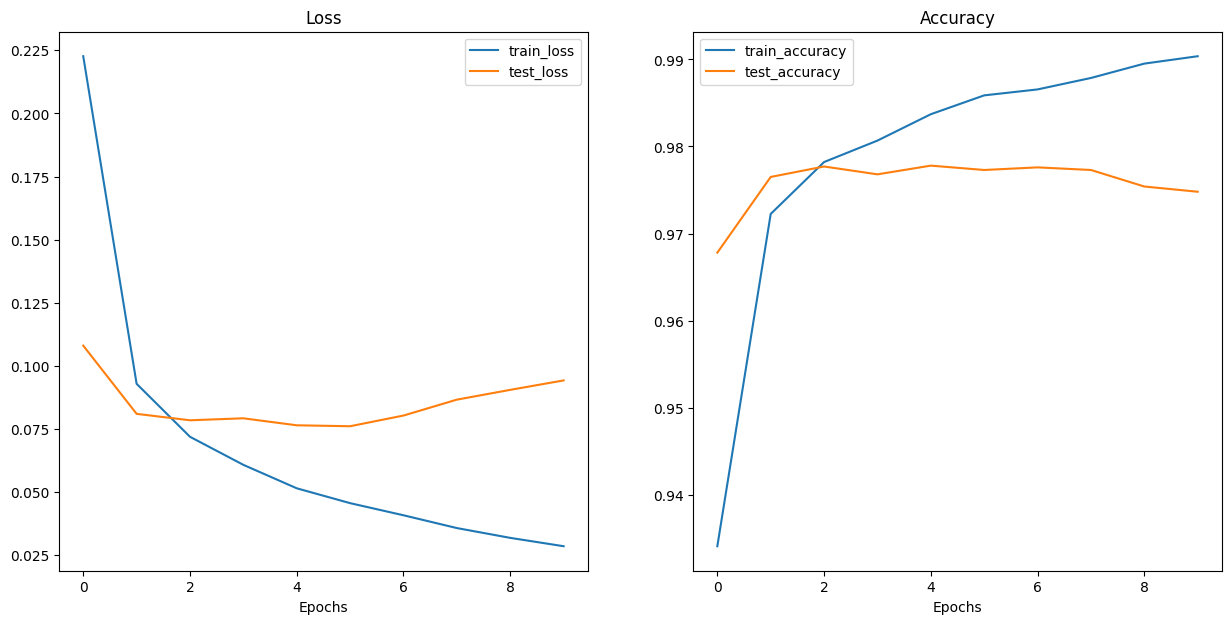

In [62]:
# Plot our ViT model's loss curves
helper_functions.plot_loss_curves(results)